# Exploratory Data Analysis (EDA)


In [22]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv", nrows=200_000)
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
print(df.head())
print(df[["click_bool", "booking_bool"]].mean())


(200000, 54)
['srch_id', 'date_time', 'site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag', 'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'srch_query_affinity_score', 'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv', 'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv', 'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv', 'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv', 'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv', 'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv', 'comp6_rate_percent_diff', 'comp7_rate', 'comp7_inv', 'comp7_rate_percent_diff', 'comp8_rate', 'comp8_inv', 'comp8_rate_percent_di

In [23]:
# `srch_id` groups with their distribution of candidates per group.
print(df.groupby("srch_id").size().describe())

count    8069.000000
mean       24.786219
std         9.168101
min         5.000000
25%        18.000000
50%        29.000000
75%        32.000000
max        37.000000
dtype: float64


In [24]:
# The click rate and booking rate, overall
print(df[["click_bool", "booking_bool"]].mean())

click_bool      0.044770
booking_bool    0.027995
dtype: float64


## Click by Search Page Position

What's the click rate and booking rate overall? How do they vary by position? (This is your position-bias evidence — plot click rate vs. position.)

click_bool     0     1
position              
1           6493  1558
2           7008  1045
3           7238   815
4           7061   733
5            389     6
6           7438   613
7           7381   479
8           7276   375
9           7174   339
10          6660   309
11           463     5
12          6901   275
13          6783   266
14          6676   223
15          6557   198
16          6059   157
17           469     2
18          6314   165
19          6165   156
20          6040   136
21          5925   122
22          5448   110
23           438     2
24          5693   100
25          5548    92
26          5413    89
27          5321    59
28          5177    78
29          5056    68
30          4904    68
31          4746    61
32          4495    61
33          4230    61
34          3995    40
35          3503    38
36          2652    40
37          1473     5
38           423     4
39            60     1
40             1     0


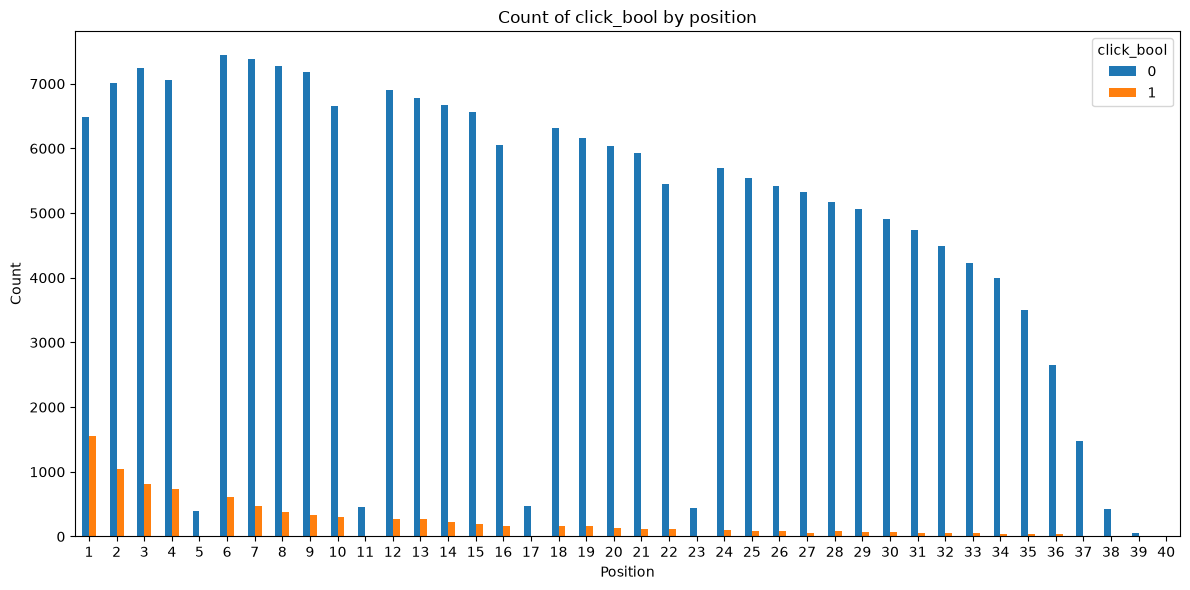

In [25]:
import matplotlib.pyplot as plt

exposure = df.groupby(["position", "click_bool"]).size().unstack(fill_value=0)
print(exposure)

ax = exposure.plot(kind="bar", figsize=(12, 6))
ax.set_title("Count of click_bool by position")
ax.set_xlabel("Position")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="click_bool")
plt.tight_layout()
plt.show()


position
1     0.193516
2     0.129765
3     0.101205
4     0.094047
5     0.015190
6     0.076140
7     0.060941
8     0.049013
9     0.045122
10    0.044339
11    0.010684
12    0.038322
13    0.037736
14    0.032324
15    0.029312
16    0.025257
17    0.004246
18    0.025467
19    0.024680
20    0.022021
21    0.020175
22    0.019791
23    0.004545
24    0.017262
25    0.016312
26    0.016176
27    0.010967
28    0.014843
29    0.013271
30    0.013677
31    0.012690
32    0.013389
33    0.014216
34    0.009913
35    0.010731
36    0.014859
37    0.003383
38    0.009368
39    0.016393
40    0.000000
Name: click_bool, dtype: float64


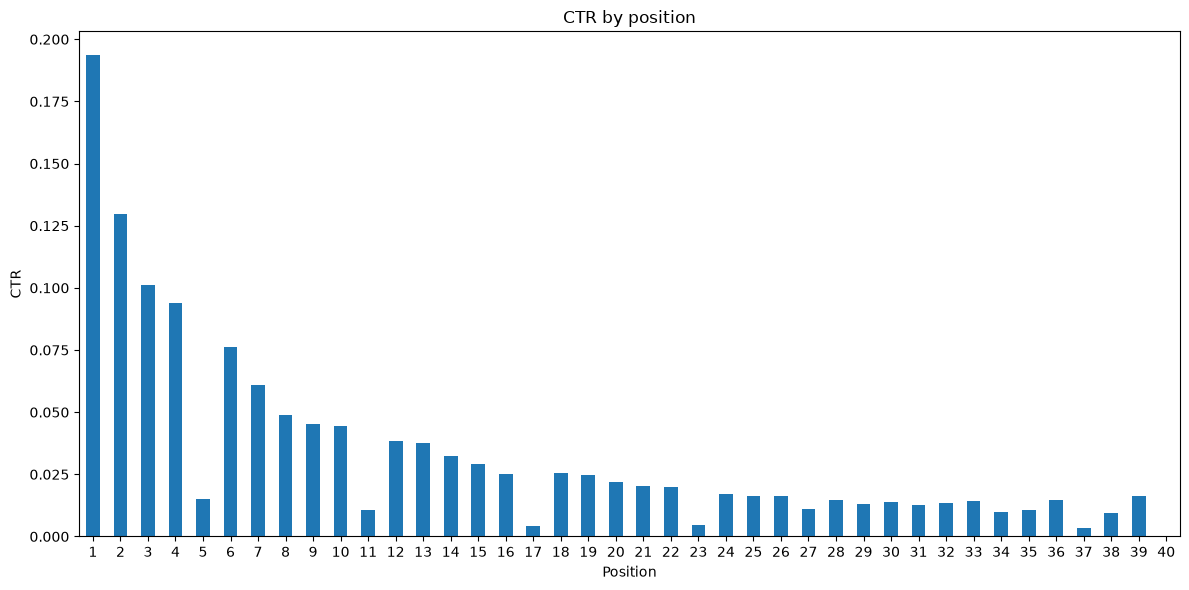

In [26]:
import matplotlib.pyplot as plt

exposure = df.groupby("position")["click_bool"].mean()
print(exposure)

ax = exposure.plot(kind="bar", figsize=(12, 6))
ax.set_title("CTR by position")
ax.set_xlabel("Position")
ax.set_ylabel("CTR")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
# ax.legend(title="click_bool")
plt.tight_layout()
plt.show()

position
1     8051
2     8053
3     8053
4     7794
5      395
6     8051
7     7860
8     7651
9     7513
10    6969
11     468
12    7176
13    7049
14    6899
15    6755
16    6216
17     471
18    6479
19    6321
20    6176
21    6047
22    5558
23     440
24    5793
25    5640
26    5502
27    5380
28    5255
29    5124
30    4972
31    4807
32    4556
33    4291
34    4035
35    3541
36    2692
37    1478
38     427
39      61
40       1
Name: click_bool, dtype: int64


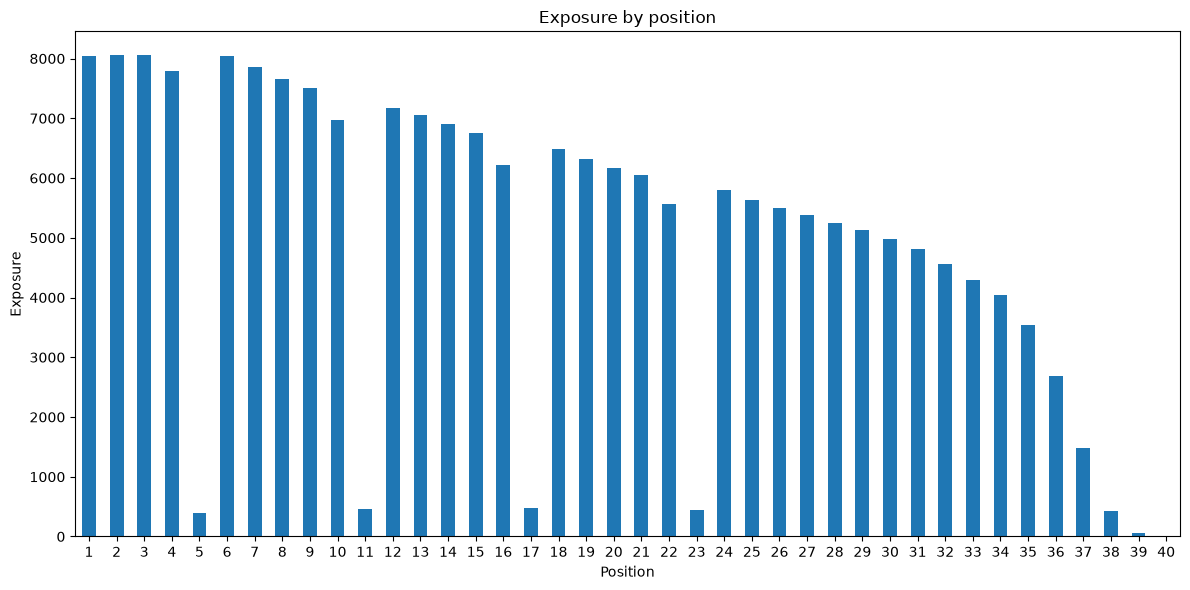

In [27]:
import matplotlib.pyplot as plt

exposure = df.groupby("position")["click_bool"].size()
print(exposure)

ax = exposure.plot(kind="bar", figsize=(12, 6))
ax.set_title("Exposure by position")
ax.set_xlabel("Position")
ax.set_ylabel("Exposure")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
# ax.legend(title="click_bool")
plt.tight_layout()
plt.show()

## Observations

Positions 5, 11, 17, and 23 show very low exposure (i.e., how frequently displayed) compared to their neighbor positions. Additionally, their click-through rates are _also_ very low (even when shown to users). This could be explained by the these positions being special search result positions, such as promoted/advertisement content. Additionally, these outliers are evenly spaced at every 6 positions. 

## Missing Data
Which columns have missing values, and how much? (Several Expedia features are sparse by design — e.g. competitor price comparisons.)# CTR = (# rows with click_bool == 1) / (total rows), per positionclick_counts = (
    df.groupby("position")["click_bool"]
      .agg(clicked="sum", total="count")
)
click_counts["ctr"] = click_counts["clicked"] / click_counts["total"]

print(click_counts[["ctr"]])

In [28]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(missing_summary.to_string(header=False))


comp1_rate_percent_diff      98.18
comp6_rate_percent_diff      97.99
comp1_rate                   97.71
comp1_inv                    97.54
comp4_rate_percent_diff      97.43
gross_bookings_usd           97.20
comp7_rate_percent_diff      97.08
comp6_rate                   94.95
visitor_hist_starrating      94.58
visitor_hist_adr_usd         94.57
comp6_inv                    94.51
comp4_rate                   93.90
srch_query_affinity_score    93.65
comp7_rate                   93.47
comp4_inv                    93.22
comp7_inv                    92.66
comp3_rate_percent_diff      90.55
comp2_rate_percent_diff      88.94
comp8_rate_percent_diff      87.82
comp5_rate_percent_diff      83.34
comp3_rate                   68.96
comp3_inv                    66.66
comp8_rate                   61.77
comp8_inv                    60.28
comp2_rate                   59.38
comp2_inv                    57.28
comp5_rate                   55.28
comp5_inv                    52.52
orig_destination_dis

## Feature Split
What's the feature split: query-level features (depend only on the search) vs. item-level features (depend on the hotel) vs. query-item interaction features? You'll need this taxonomy for the two-tower model in Days 3–4.

- Query: Those relevant to a users's search query
- Item: Relevant to the hotel (or item)
- Query-Item Interaction: User clicked on hotel (?)

|Column Name | Data Type | Description | Feature Type |
|-|-|-|-|
|srch_id | Integer | The ID of the search | Query |
|date_time | Date/time | Date and time of the search | Query |
|site_id | Integer | ID of the Expedia point of sale (i.e. Expedia.com, Expedia.co.uk, Expedia.co.jp, ..) | Query |
|visitor_location_country_id | Integer | The ID of the country the customer is located | Query |
|visitor_hist_starrating | Float | The mean star rating of hotels the customer has previously purchased; null signifies there is no purchase history on the customer | Query |
|visitor_hist_adr_usd | Float | The mean price per night (in US$) of the hotels the customer has previously purchased; null signifies there is no purchase history on the customer |Query|
|prop_country_id | Integer | The ID of the country the hotel is located in |Item|
|prop_id | Integer | The ID of the hotel |Item|
|prop_starrating | Integer | The star rating of the hotel, from 1 to 5, in increments of 1.  A 0 indicates the property has no stars, the star rating is not known or cannot be publicized. |Item|
|prop_review_score | Float | The mean customer review score for the hotel on a scale out of 5, rounded to 0.5 increments. A 0 means there have been no reviews, null that the information is not available. |Item|
|prop_brand_bool | Integer | +1 if the hotel is part of a major hotel chain; 0 if it is an independent hotel |Item|
|prop_location_score1 | Float | A (first) score outlining the desirability of a hotel’s location |Item|
|prop_location_score2 | Float | A (second) score outlining the desirability of the hotel’s location |Item|
|prop_log_historical_price | Float | The logarithm of the mean price of the hotel over the last trading period. A 0 will occur if the hotel was not sold in that period. |Item|
|position | Integer | Hotel position on Expedia's search results page. This is only provided for the training data, but not the test data. |Query-Item|
|price_usd | Float | Displayed price of the hotel for the given search.  Note that different countries have different conventions regarding displaying taxes and fees and the value may be per night or for the whole stay |Query-Item|
|promotion_flag | Integer | +1 if the hotel had a sale price promotion specifically displayed |Query-Item|
|gross_booking_usd | Float | Total value of the transaction.  This can differ from the price_usd due to taxes, fees, conventions on multiple day bookings and purchase of a room type other than the one shown in the search |Query-Item|
|srch_destination_id | Integer | ID of the destination where the hotel search was performed |Query|
|srch_length_of_stay | Integer | Number of nights stay that was searched |Query|
|srch_booking_window | Integer | Number of days in the future the hotel stay started from the search date |Query|
|srch_adults_count | Integer | The number of adults specified in the hotel room |Query|
|srch_children_count | Integer | The number of (extra occupancy) children specified in the hotel room |Query|
|srch_room_count | Integer | Number of hotel rooms specified in the search |Query|
|srch_saturday_night_bool | Boolean | +1 if the stay includes a Saturday night, starts from Thursday with a length of stay is less than or equal to 4 nights (i.e. weekend); otherwise 0 |Query|
|srch_query_affinity_score | Float | The log of the probability a hotel will be clicked on in Internet searches (hence the values are negative) A null signifies there are no data (i.e. hotel did not register in any searches) |Item|
|orig_destination_distance | Float | Physical distance between the hotel and the customer at the time of search. A null means the distance could not be calculated. |Item|
|random_bool | Boolean | +1 when the displayed sort was random, 0 when the normal sort order was displayed |Query-Item|
|compX_rate | Integer | +1 if Expedia has a lower price than competitor X for the hotel; 0 if the same; -1 if Expedia’s price is higher than competitor X; null signifies there is no competitive data |Query-Item|
|compX_inv | Integer | +1 if competitor X does not have availability in the hotel; 0 if both Expedia and competitor X have availability; null signifies there is no competitive data |Query-Item|
|compX_rate_percent_diff | Float | The absolute percentage difference (if one exists) between Expedia and competitor X’s price (Expedia’s price the denominator); null signifies there is no competitive data |Query-Item|

In [29]:
from src.data_stats import summarize

summarize(
    df,
    group_col="srch_id",
    label_cols=["click_bool", "booking_bool"],
    position_col="position",
)

Rows: 200,000
Unique Groups (srch_id): 8,069
Group size distribution:
count    8069.000000
mean       24.786219
std         9.168101
min         5.000000
25%        18.000000
50%        29.000000
75%        32.000000
max        37.000000
dtype: float64
Label base rates:
click_bool      0.044770
booking_bool    0.027995
dtype: float64
Click/Booking rate by position (top 10):
          click_bool  booking_bool
position                          
1           0.193516      0.139983
2           0.129765      0.088414
3           0.101205      0.070036
4           0.094047      0.060944
5           0.015190      0.012658
6           0.076140      0.051422
7           0.060941      0.038804
8           0.049013      0.030454
9           0.045122      0.025822
10          0.044339      0.025685
Missingness (top 15 columns by % missing):
comp1_rate_percent_diff      0.981755
comp6_rate_percent_diff      0.979900
comp1_rate                   0.977110
comp1_inv                    0.975390
comp4_ra

In [30]:
from src.features import make_label
label = make_label(df)
print(label.value_counts().sort_index())

print(pd.crosstab(df["click_bool"], df["booking_bool"]))

click_bool
0    191046
1      3355
5      5599
Name: count, dtype: int64
booking_bool       0     1
click_bool                
0             191046     0
1               3355  5599


Takeaways
- All bookings were clicked
- Clicks have a ~62% conversion rate
